## 2. Single Qubit Operations: Visualizing quantum processes

In this notebook, you will learn what single-qubit operations are, how they act in single-qubit systems, and how to visualize this action. More concretely, you will learn about the X gate, the Z gate and the Hadamard gate and how they relate to each other, as well as how they work in the circle notation (CN) visualization and rotations on the Bloch sphere. Then, we will discuss the intricacies of quantum measurements as in the quantum world these are, also, operations.

## 2.1. The Pauli-X and Pauli-Z Gates

Single-qubit gates are unitary operators (unitary means $UU^\dagger=\mathbb{1}$) acting on a two-dimensional Hilbert space. Let us consider an arbitrary single-qubit state $|\psi\rangle$:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle = \begin{pmatrix} \alpha \\ \beta \end{pmatrix}$$

where $\alpha, \beta \in \mathbb{C}$ and $|\alpha|^2 + |\beta|^2 = 1$. In the following, it is described how the X, Z, and H gates, which are fundamental to quantum information processing, act on this general one-qubit state.

### The X Gate (Bit-Flip)
<div style="background-color: #6ab2e7; color: #042c58; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
The Pauli-X gate is the quantum equivalent of the classical NOT gate. It maps the computational basis state $|0\rangle \to |1\rangle$ and $|1\rangle \to |0\rangle$.
</div>

**Matrix Representation:**
$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

**Action on $|\psi\rangle$:**
$$X \begin{pmatrix} \alpha \\ \beta \end{pmatrix} = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} \begin{pmatrix} \alpha \\ \beta \end{pmatrix} = \begin{pmatrix} \beta \\ \alpha \end{pmatrix}$$

The amplitudes are swapped. If the qubit was in state $|0\rangle$ ($\alpha=1, \beta=0$), it flips to $|1\rangle$ ($\alpha=0, \beta=1$). In circle notation (CN), the X gate flips the inner circles and gauge lines:

<img src="images/X_gate_CN.png" width="1000">

### The Z Gate (Phase-Flip)
<div style="background-color: #6ab2e7; color: #042c58; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
The Pauli-Z gate leaves the basis states $|0\rangle$ and $|1\rangle$ unchanged in terms of bit value (probability) but introduces a relative phase of $\pi$ (multiplying by -1) to the $|1\rangle$ component.
</div>

**Matrix Representation:**
$$Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$

**Action on $|\psi\rangle$:**
$$Z \begin{pmatrix} \alpha \\ \beta \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} \begin{pmatrix} \alpha \\ \beta \end{pmatrix} = \begin{pmatrix} \alpha \\ -\beta \end{pmatrix}$$

Critically, the Z gate has no effect on the probability amplitudes if measured in the standard basis, as $|\alpha|^2$ and $|-\beta|^2$ are identical. Its effect is only observable when considering interference or measuring in a different basis (like the X basis).


In CN, the Z gate flips the phase of the gauge line on the right:

<img src="images/Z_gate_CN.png" width="1000">

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qc_education_package import DimensionalCircleNotation

# Create a circuit with 1 qubit
qc_xz = QuantumCircuit(1)

# Apply X gate: |0> -> |1>
qc_xz.x(0)

# Apply Z gate: |1> -> -|1>
qc_xz.z(0)

# Visualize the circuit
qc_xz.draw(output="mpl")

# Check the state vector
state = Statevector.from_instruction(qc_xz)
print("\nStatevector after X and Z:", state.data)

# Visualize in Circle Notation
DimensionalCircleNotation.from_qiskit(state).show()


Statevector after X and Z: [ 0.+0.j -1.+0.j]


<Figure size 640x480 with 1 Axes>

## 2.2. The Hadamard Gate (Superposition)

<div style="background-color: #6ab2e7; color: #042c58; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
The Hadamard gate (H) is perhaps the most critical single-qubit gate because it generates superposition from computational basis states. It maps the basis states $|0\rangle$ and $|1\rangle$ to the eigenstates of the X operator, $|+\rangle$ and $|-\rangle$.
</div>

**Matrix Representation:**
$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

**Action on Basis States:**
$$H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} = |+\rangle$$
$$H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}} = |-\rangle$$

The H gate corresponds to a basis change. It transforms states from the Z-basis (computational basis) to the X-basis (superposition basis). This operation is essential for all quantum algorithms to take advantage of quantum effects, for example those that rely on quantum interference to cancel out wrong answers and amplify correct ones, but also because different parts of the superposition can behave differently under certain conditions, and such superpositions therefore allow for a quantum parallelism. In CN, the Hadamard gate splits states that are classical (either 0 or 1). When going from right to left, it introduces a phase flip on the right gauge:

<img src="images/H_gate_CN.png" width="1000">

## 2.3. Visualization on the Bloch Sphere

As seen in the previous notebook, the **Bloch sphere** is a geometric representation of the pure state space of a two-level quantum system. Any pure state $|\psi\rangle$ can be written as:

$$|\psi\rangle = \cos\left(\frac{\vartheta}{2}\right)|0\rangle + e^{i\varphi}\sin\left(\frac{\vartheta}{2}\right)|1\rangle$$

where $\vartheta$ and $\varphi$ are the polar and azimuthal angles, respectively.

### Geometric Action of Gates
* **X Gate:** Corresponds to a rotation of $\pi$ (180°) around the x-axis. It moves a state from the north pole ($|0\rangle$) to the south pole ($|1\rangle$).
* **Z Gate:** Corresponds to a rotation of $\pi$ around the z-axis. It changes the phase $\phi$, rotating the state vector along the equator (if it acts on a superposition state like $|+\rangle$).
* **H Gate:** Geometrically, H can be viewed as a rotation of $\pi$ around the diagonal axis defined by $(x+z)/\sqrt{2}$. Alternatively, it is often decomposed as a rotation around the Y-axis by $\pi/2$ followed by a rotation around the X-axis by $\pi$. It effectively swaps the axes: $X \leftrightarrow Z$.

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
Your Task: Find out what the operations HXH and HZH equal to (visually, using Dirac notation, or matrices).
</div>

To do this, you can also check out our interactive visualization tool:

In [2]:
from qc_education_package import InteractiveDCNViewer
viewer = InteractiveDCNViewer(num_qubits=1)
viewer.display()

Or try out the challenge mode:

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
Challenge: use the interactive DCN viewer to get from the state $1/\sqrt{2}\ket{0}-1/\sqrt{2}\ket{1}$ to the state $\ket{0}$
</div>

In [3]:
from qc_education_package import ChallengeDCNViewer

# Initialize the student challenge: Go from |-> to |0>
viewer = ChallengeDCNViewer(
    num_qubits=1,
    initial_state=[1, -1],  # 1/sqrt(2) (|0> - |1>)
    target_state=[1, 0]     # |0>
)

viewer.display()

Step,Circuit Diagram,Dimensional Circle Notation (DCN),Bloch Sphere
Initial State $|0\rangle$,,,
Apply H Gate ($|+\rangle$),,,
Apply Z Gate ($|-\rangle$),,,
Apply H Gate ($|1\rangle$),,,

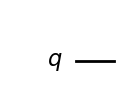
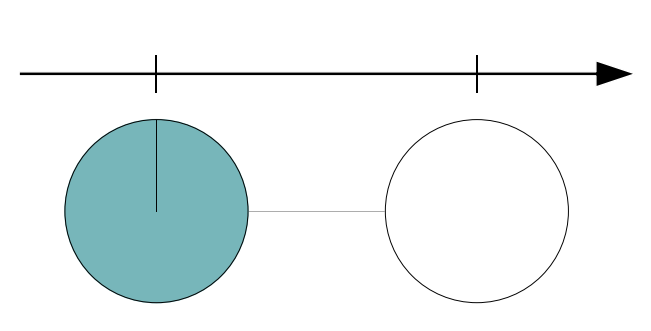
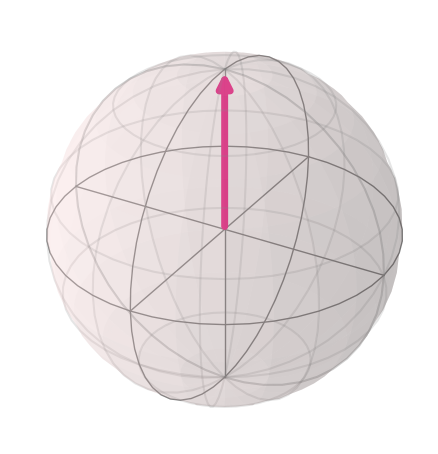
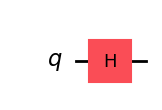
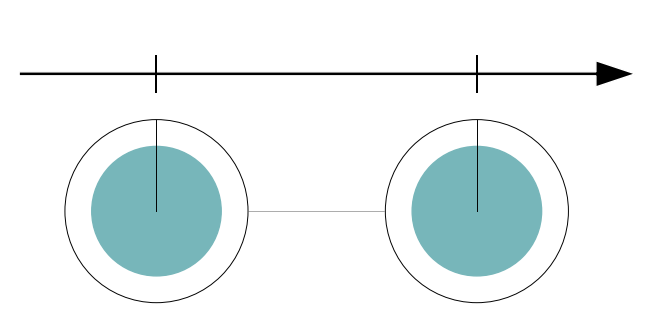
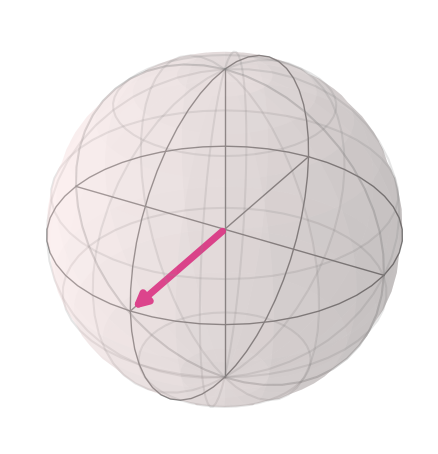
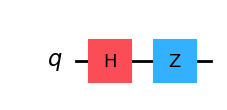
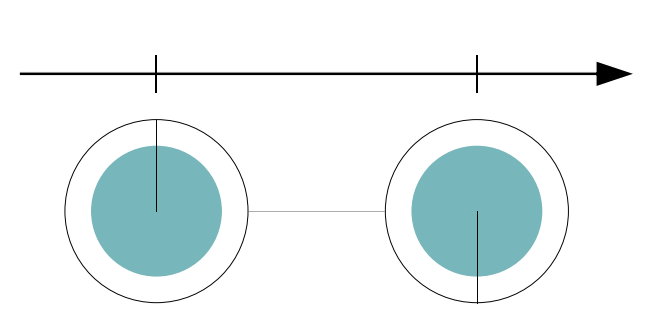
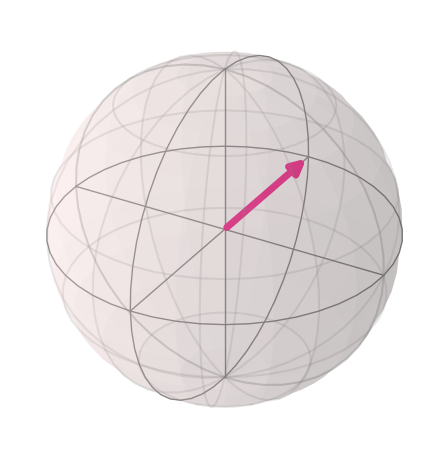
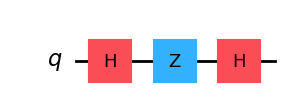
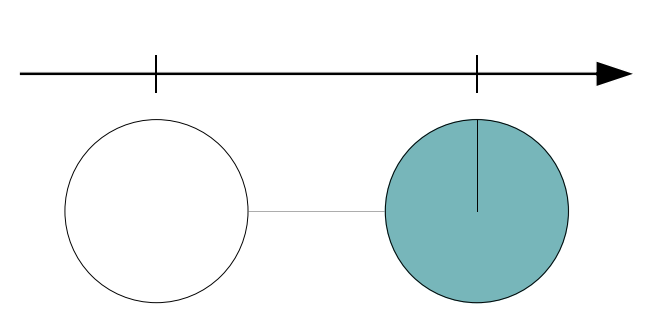
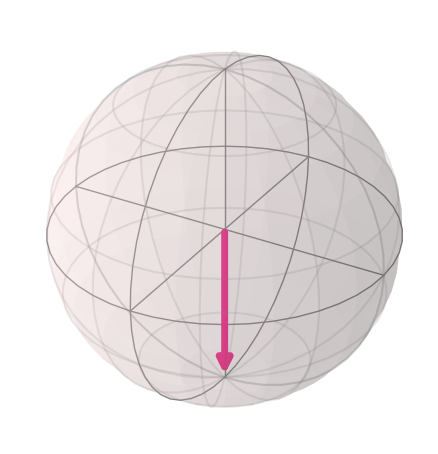

In [4]:
import matplotlib.pyplot as plt
from io import BytesIO
import base64
from IPython.display import display, HTML

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# Custom Package Imports
from qc_education_package import DimensionalCircleNotation

# --- Helper Function for converting Figures to Base64 ---
def fig_to_base64(fig):
    """Converts a matplotlib figure to a base64 string for HTML embedding."""
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', transparent=True)
    plt.close(fig) # Close the figure to prevent plotting in the notebook output
    return base64.b64encode(buf.getvalue()).decode('utf-8')

# --- 1. Define the Steps and Capture Data ---
steps_data = []

# Step 0: Initial |0>
qc = QuantumCircuit(1)
state_0 = Statevector.from_instruction(qc)
# Draw the circuit (snapshot)
fig_circ_0 = qc.draw(output="mpl")
steps_data.append(("Initial State $|0\\rangle$", state_0, fig_circ_0))

# Step 1: Apply H -> |+>
qc.h(0)
state_h = Statevector.from_instruction(qc)
fig_circ_h = qc.draw(output="mpl")
steps_data.append(("Apply H Gate ($|+\\rangle$)", state_h, fig_circ_h))

# Step 2: Apply Z -> |->
qc.z(0)
state_z = Statevector.from_instruction(qc)
fig_circ_z = qc.draw(output="mpl")
steps_data.append(("Apply Z Gate ($|-\\rangle$)", state_z, fig_circ_z))

# Step 3: Apply H -> |1>
qc.h(0)
state_final = Statevector.from_instruction(qc)
fig_circ_final = qc.draw(output="mpl")
steps_data.append(("Apply H Gate ($|1\\rangle$)", state_final, fig_circ_final))


# --- 2. Build the HTML Table ---
html_table = """
<style>
    table.gates {width: 100%; border-collapse: collapse; text-align: center; font-family: sans-serif;}
    table.gates th {padding: 12px; border: 1px solid #ddd;}
    table.gates td {padding: 10px; border: 1px solid #ddd; vertical-align: middle;}
    .step-name {font-weight: bold; font-size: 1.1em;}
</style>
<table class="gates">
    <tr>
        <th>Step</th>
        <th>Circuit Diagram</th>
        <th>Dimensional Circle Notation (DCN)</th>
        <th>Bloch Sphere</th>
    </tr>
"""

for step_name, state, fig_circ in steps_data:
    # A. Generate Circuit Image
    circ_b64 = fig_to_base64(fig_circ)

    # B. Generate DCN Image
    dcn_b64 = DimensionalCircleNotation.from_qiskit(state).exportBase64("png")

    # C. Generate Bloch Sphere Image
    bloch_fig = plot_bloch_multivector(state)
    bloch_b64 = fig_to_base64(bloch_fig)

    # D. Add Row to Table
    html_table += f"""
    <tr>
        <td class="step-name">{step_name}</td>
        <td><img src="data:image/png;base64,{circ_b64}" style="max-width: 250px;"></td>
        <td><img src="data:image/png;base64,{dcn_b64}" width="200"></td>
        <td><img src="data:image/png;base64,{bloch_b64}" width="200"></td>
    </tr>
    """

html_table += "</table>"

# --- 3. Display the Result ---
display(HTML(html_table))

## 2.4. Measurements

In classical physics, measurement is a passive act—reading a value does not change the system. In quantum mechanics, measurement is an active operation that collapses the wavefunction.

Mathematically, a projective measurement in the computational basis $\{|0\rangle, |1\rangle\}$ is described by projection operators:
$$P_0 = |0\rangle\langle0| \quad \text{and} \quad P_1 = |1\rangle\langle1|.$$

Because the computational basis is an orthonormal basis, we have $\langle 0 | 0 \rangle=\langle 1 | 1 \rangle=1$ and $\langle 0 | 1 \rangle=\langle 1 | 0 \rangle=0$. When we measure a state $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$:

1.  **Probability (Born Rule):** The probability of measuring outcome $x$ is:
    $$p(x) = \langle\psi|P_x|\psi\rangle = |\langle x | \psi \rangle|^2$$
2.  **Collapse:** Immediately after measurement, the state becomes the projected state:
    $$|\psi'\rangle = \frac{P_x|\psi\rangle}{\sqrt{p(x)}} = |x\rangle$$

This non-reversible collapse distinguishes measurement from the unitary gates (X, Z, H) discussed above. Let's take the state $|\psi\rangle=\frac{\sqrt{3}}{2}|0\rangle+\frac{1}{2}|1\rangle$ as an example. The Born Rule for measuring 0 with the projection operator $P_0=|0\rangle\langle0|$ yields

$$ p(0) = \langle\psi|P_0|\psi\rangle = |\langle 0 | \psi \rangle|^2 = |\frac{\sqrt{3}}{2}\langle 0|0\rangle+\frac{1}{2}\langle 0|1\rangle|^2=\left|\frac{\sqrt{3}}{2}\right|^2=\frac{3}{4}.$$

Similarly,

$$ p(1) = \langle\psi|P_1|\psi\rangle = |\langle 1 | \psi \rangle|^2 = |\frac{\sqrt{3}}{2}\langle 1|0\rangle+\frac{1}{2}\langle 1|1\rangle|^2=\left|\frac{1}{2}\right|^2=\frac{1}{4}.$$

After the measurement, depending on the result (which is given by random chance), the state of the system will be $|0\rangle$ or $|1\rangle$, depending on the respective measurement result. Visually, the measurement looks like this:

<img src="images/measurements_CN.png" width="1000">

Dimensional Circle Notation,Bloch Sphere,Circuit Diagram,Measurement Histogram
,,,

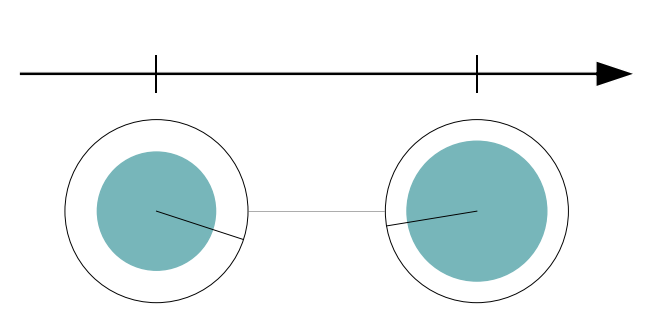
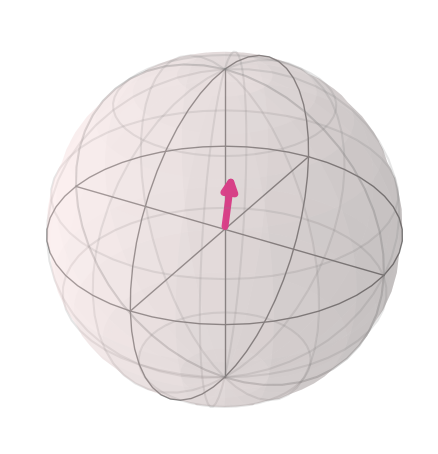
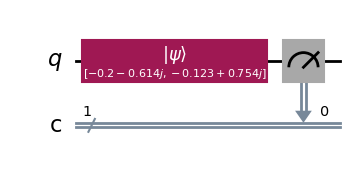
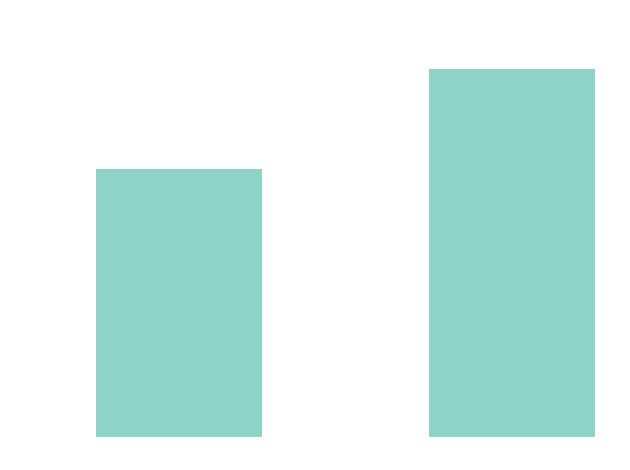

In [5]:
import matplotlib.pyplot as plt
from io import BytesIO
import base64
from IPython.display import display, HTML

# Qiskit Imports
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import random_statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram, array_to_latex
from qiskit_aer import AerSimulator

# Custom Package Imports
from qc_education_package import DimensionalCircleNotation

# --- Helper Functions ---
def fig_to_base64(fig):
    """Converts a matplotlib figure to a base64 string for HTML embedding."""
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', transparent=True)
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

def latex_to_html(latex_obj):
    """Extracts raw LaTeX string from Qiskit's Latex object."""
    return latex_obj.data.replace('$$', '')

# --- 1. Generate & Process Data ---

# A. Generate Random State
psi = random_statevector(2)

# B. Prepare Statevector LaTeX (For display ABOVE table)
psi_latex = array_to_latex(psi, prefix="|\\psi\\rangle = ")
psi_math_str = latex_to_html(psi_latex)

# C. Generate DCN Image
dcn_b64 = DimensionalCircleNotation.from_qiskit(psi).exportBase64("png")

# D. Generate Bloch Sphere Image
bloch_fig = plot_bloch_multivector(psi)
bloch_b64 = fig_to_base64(bloch_fig)

# E. Create Circuit & Simulate
qc = QuantumCircuit(1, 1)
qc.initialize(psi, 0)
qc.measure(0, 0)

# F. Generate Circuit Diagram
circ_fig = qc.draw(output="mpl")
circ_b64 = fig_to_base64(circ_fig)

# G. Simulate & Generate Histogram
simulator = AerSimulator()
transpiled_qc = transpile(qc, simulator)
result = simulator.run(transpiled_qc, shots=1024).result()
counts = result.get_counts()

hist_fig = plot_histogram(counts, title="Measurement Results")
hist_b64 = fig_to_base64(hist_fig)

# --- 2. Build HTML Output ---
html_output = f"""
<style>
    .state-header {{
        font-size: 1.3em;
        text-align: center;
        margin-bottom: 20px;
        padding: 10px;
        border: 1px solid #ddd;
    }}
    table.measure {{width: 100%; border-collapse: collapse; text-align: center; font-family: sans-serif;}}
    table.measure th {{padding: 10px; border: 1px solid #ddd;}}
    table.measure td {{padding: 10px; border: 1px solid #ddd; vertical-align: middle;}}
</style>

<div class="state-header">
    <b>Generated State:</b> $${psi_math_str}$$
</div>

<table class="measure">
    <tr>
        <th>Dimensional Circle Notation</th>
        <th>Bloch Sphere</th>
        <th>Circuit Diagram</th>
        <th>Measurement Histogram</th>
    </tr>
    <tr>
        <td><img src="data:image/png;base64,{dcn_b64}" width="180"></td>
        <td><img src="data:image/png;base64,{bloch_b64}" width="180"></td>
        <td><img src="data:image/png;base64,{circ_b64}" style="max-width: 200px;"></td>
        <td><img src="data:image/png;base64,{hist_b64}" width="250"></td>
    </tr>
</table>
"""

# --- 3. Display ---
display(HTML(html_output))

## 2.5. Excourse: Rotation gates on the Bloch sphere

While the Pauli gates ($X, Y, Z$) represent discrete $180^\circ$ ($\pi$) rotations around their respective axes, quantum computers can perform arbitrary rotations. These are described by the **Rotation Gates**: $R_x(\theta)$, $R_y(\theta)$, and $R_z(\theta)$.

### Matrix Representations
A rotation by an angle $\theta$ around a specific axis on the Bloch sphere is given by the exponentiation of the corresponding Pauli matrix.

**Rotation around X-axis:**
$$
R_x(\theta) = e^{-i\frac{\theta}{2}X} = \begin{pmatrix}
\cos\frac{\theta}{2} & -i\sin\frac{\theta}{2} \\
-i\sin\frac{\theta}{2} & \cos\frac{\theta}{2}
\end{pmatrix}
$$

**Rotation around Y-axis:**
$$
R_y(\theta) = e^{-i\frac{\theta}{2}Y} = \begin{pmatrix}
\cos\frac{\theta}{2} & -\sin\frac{\theta}{2} \\
\sin\frac{\theta}{2} & \cos\frac{\theta}{2}
\end{pmatrix}
$$

**Rotation around Z-axis:**
$$
R_z(\theta) = e^{-i\frac{\theta}{2}Z} = \begin{pmatrix}
e^{-i\frac{\theta}{2}} & 0 \\
0 & e^{i\frac{\theta}{2}}
\end{pmatrix}
$$

### Equivalency to Pauli Gates
It is important to note that a "full" rotation in the Pauli group corresponds to $\theta = \pi$ ($180^\circ$).
* $R_x(\pi) = -iX$
* $R_y(\pi) = -iY$
* $R_z(\pi) = -iZ$

These are equivalent to the standard Pauli gates up to a **global phase** factor of $-i$ (or $e^{-i\pi/2}$). Since global phases are physically unobservable, $R_x(\pi)$ performs the same logical bit-flip operation as $X$.

### Visualizing $\pi/2$ Rotations
Rotations by $\theta = \pi/2$ create superposition states. For example, $R_y(\pi/2)$ transforms basis states into the eigenstates of the X-operator ($|+\rangle, |-\rangle$).

The table below visualizes the effect of applying $R_x(\pi/2)$, $R_y(\pi/2)$, and $R_z(\pi/2)$ to the basis states $|0\rangle$ and $|1\rangle$.

Operation,Resulting Vector,Dimensional Circle Notation,Bloch Sphere
$$R_x(\pi/2)|0\rangle$$,$$ R_x(\pi/2)|0\rangle = \begin{bmatrix} \frac{\sqrt{2}}{2} & - \frac{\sqrt{2} i}{2} \\ \end{bmatrix} $$,,
$$R_x(\pi/2)|1\rangle$$,$$ R_x(\pi/2)|1\rangle = \begin{bmatrix} - \frac{\sqrt{2} i}{2} & \frac{\sqrt{2}}{2} \\ \end{bmatrix} $$,,
$$R_y(\pi/2)|0\rangle$$,$$ R_y(\pi/2)|0\rangle = \begin{bmatrix} \frac{\sqrt{2}}{2} & \frac{\sqrt{2}}{2} \\ \end{bmatrix} $$,,
$$R_y(\pi/2)|1\rangle$$,$$ R_y(\pi/2)|1\rangle = \begin{bmatrix} - \frac{\sqrt{2}}{2} & \frac{\sqrt{2}}{2} \\ \end{bmatrix} $$,,
$$R_z(\pi/2)|0\rangle$$,$$ R_z(\pi/2)|0\rangle = \begin{bmatrix} \frac{\sqrt{2}}{2} - \frac{\sqrt{2} i}{2} & 0 \\ \end{bmatrix} $$,,
$$R_z(\pi/2)|1\rangle$$,$$ R_z(\pi/2)|1\rangle = \begin{bmatrix} 0 & \frac{\sqrt{2}}{2} + \frac{\sqrt{2} i}{2} \\ \end{bmatrix} $$,,

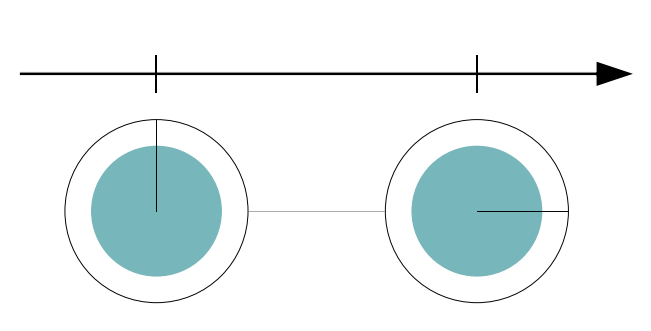
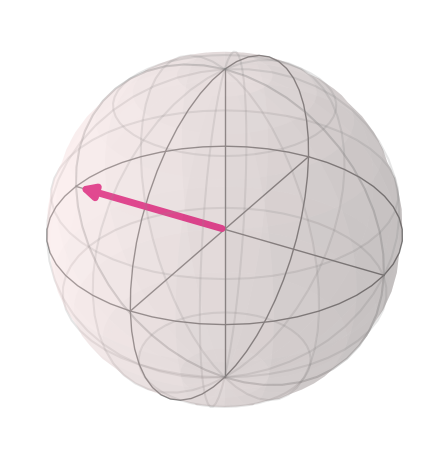
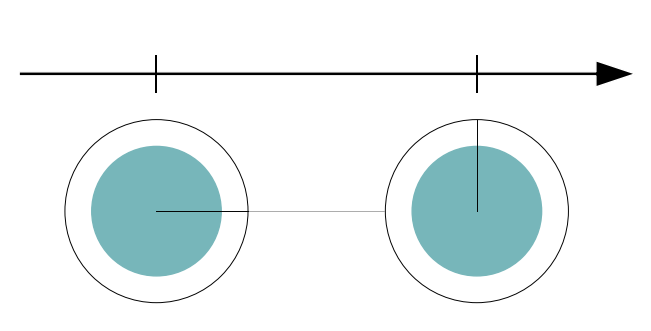
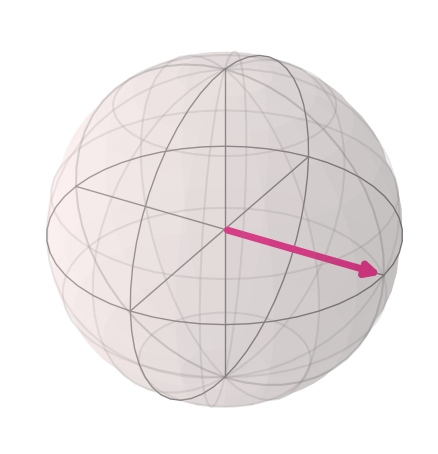
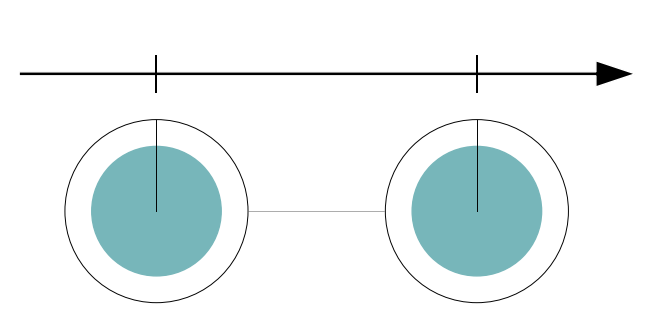
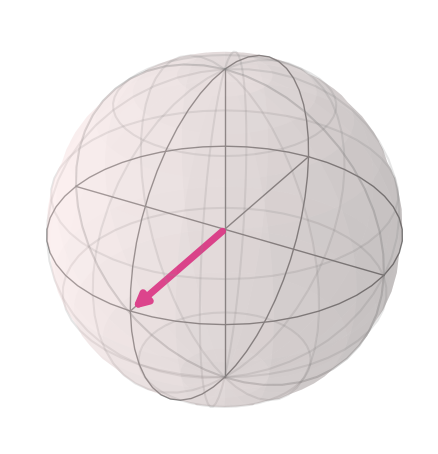
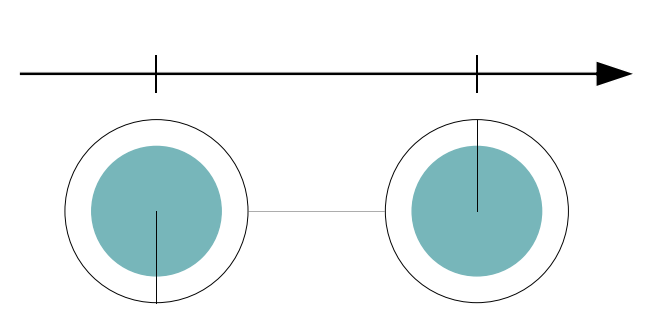
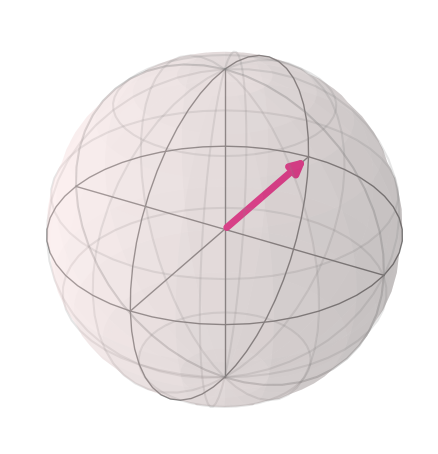
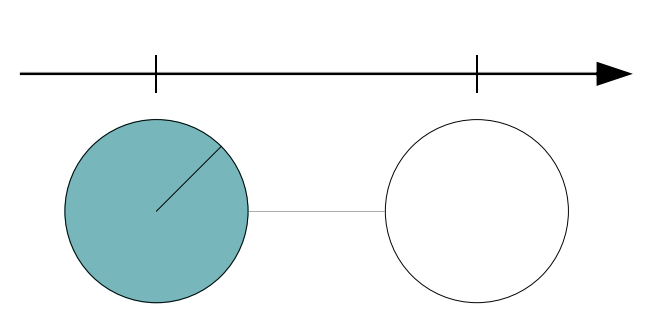
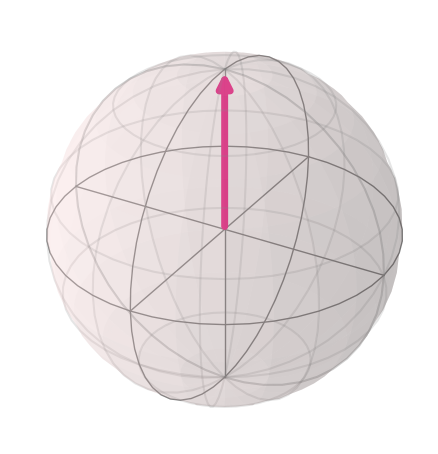
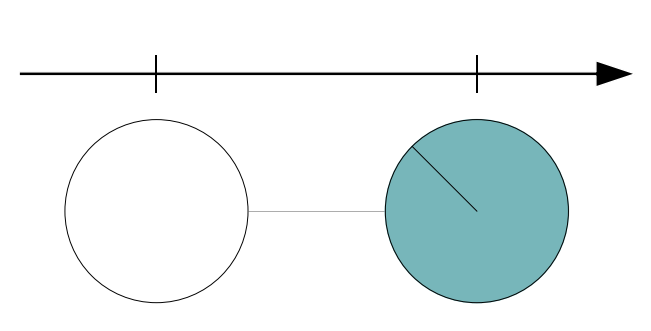
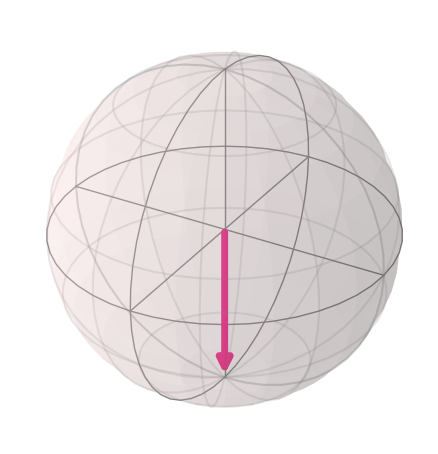

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import base64
from IPython.display import display, HTML

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit.visualization import array_to_latex, plot_bloch_multivector
from qiskit.quantum_info import Statevector

# Custom Package Imports
from qc_education_package import Simulator, DimensionalCircleNotation

def fig_to_base64(fig):
    """Converts a matplotlib figure to a base64 string for HTML embedding."""
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', transparent=True)
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

def latex_to_html(latex_obj):
    """Extracts raw LaTeX string from Qiskit's Latex object."""
    return latex_obj.data.replace('$$', '')

# Define the operations to visualize
# Format: (Label Name, Initial State Label, Rotation Axis, Angle)
operations = [
    (r"R_x(\pi/2)|0\rangle", 0, 'x', np.pi/2),
    (r"R_x(\pi/2)|1\rangle", 1, 'x', np.pi/2),
    (r"R_y(\pi/2)|0\rangle", 0, 'y', np.pi/2),
    (r"R_y(\pi/2)|1\rangle", 1, 'y', np.pi/2),
    (r"R_z(\pi/2)|0\rangle", 0, 'z', np.pi/2),
    (r"R_z(\pi/2)|1\rangle", 1, 'z', np.pi/2),
]

html_table = """
<style>
    table.rots {width: 100%; border-collapse: collapse; text-align: center;}
    table.rots th {background-color: #f2f2f2; padding: 10px; border: 1px solid #ddd;}
    table.rots td {padding: 10px; border: 1px solid #ddd; vertical-align: middle;}
    .math-font {font-size: 1.1em;}
</style>
<table class="rots">
    <tr>
        <th>Operation</th>
        <th>Resulting Vector</th>
        <th>Dimensional Circle Notation</th>
        <th>Bloch Sphere</th>
    </tr>
"""

for label, init_state, axis, angle in operations:
    # 1. Create Circuit
    qc = QuantumCircuit(1)

    # Prepare initial state (default is |0>)
    if init_state == 1:
        qc.x(0)

    # Apply Rotation
    if axis == 'x':
        qc.rx(angle, 0)
    elif axis == 'y':
        qc.ry(angle, 0)
    elif axis == 'z':
        qc.rz(angle, 0)

    # 2. Get Statevector
    sv = Statevector.from_instruction(qc)

    # 3. Generate LaTeX
    latex_obj = array_to_latex(sv, prefix=f"{label} = ")
    math_str = f"$${latex_to_html(latex_obj)}$$"

    # 4. Generate DCN Image
    # Bridge to custom simulator
    sim_vis = Simulator(1)
    sim_vis.writeComplex(sv.data)
    dcn = DimensionalCircleNotation(sim_vis)
    b64_dcn = dcn.exportBase64(formatStr="png")

    # 5. Generate Bloch Sphere Image
    bloch_fig = plot_bloch_multivector(sv)
    b64_bloch = fig_to_base64(bloch_fig)

    # 6. Add Row
    html_table += f"""
    <tr>
        <td class="math-font"><b>$${label}$$</b></td>
        <td>{math_str}</td>
        <td><img src="data:image/png;base64,{b64_dcn}" width="180"></td>
        <td><img src="data:image/png;base64,{b64_bloch}" width="180"></td>
    </tr>
    """

html_table += "</table>"
display(HTML(html_table))

plt.close('all')

In [7]:
from qc_education_package import InteractiveDCNViewer

viewer = InteractiveDCNViewer(num_qubits=1,initial_state=[1,-1])
viewer.display()

<div style="background-color: #6ab2e7; color: #042c58; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
The rotations on the Bloch sphere are enough to make any single-qubit operation possible. Therefore, they form a set of universal gates for single-qubit systems.
</div>

In the following notebooks, you will learn how to apply these single-qubit operations in order to securely transfer quantum information.